# English-to-Fake Experiment Overview

This notebook is a polished walkthrough of the final project results. It covers the complete story from behavior to mechanism:

- main behavior result
- Fake comprehension control
- hidden-state similarity
- activation patching
- paper-ready figures

The goal is to make it easy to review the whole project without jumping between many files.


## 1. Load Paths and Utilities

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display, Markdown

ROOT = Path.cwd()
PROJECT_ROOT = ROOT if (ROOT / 'notebooks').exists() else ROOT.parent
OUTPUTS = PROJECT_ROOT / 'outputs'

FIG_ROOT = OUTPUTS / 'figures' / 'llama31_8b_main_qlora' / 'main_qlora'
ANALYSIS_ROOT = OUTPUTS / 'analysis' / 'llama31_8b_main_qlora'
MAIN_METRICS_PATH = OUTPUTS / 'metrics' / 'llama31_8b_main_qlora' / 'default' / 'metrics.json'
CONTROL_METRICS_PATH = OUTPUTS / 'metrics' / 'llama31_8b_fake_control_qlora' / 'default' / 'metrics.json'
SIM_TEST_OVERALL = ANALYSIS_ROOT / 'main_qlora' / 'test' / 'overall.json'
SIM_TEST_BY_REL = ANALYSIS_ROOT / 'main_qlora' / 'test' / 'by_relation.json'
PATCH_OVERALL = ANALYSIS_ROOT / 'patching' / 'main_qlora' / 'overall.json'
PATCH_BY_REL = ANALYSIS_ROOT / 'patching' / 'main_qlora' / 'by_relation.json'
PATCH_SELECTION = ANALYSIS_ROOT / 'patching' / 'main_qlora' / 'selection_summary.json'

for path in [
    MAIN_METRICS_PATH,
    CONTROL_METRICS_PATH,
    SIM_TEST_OVERALL,
    PATCH_OVERALL,
    PATCH_SELECTION,
]:
    print(f'{path}:', 'OK' if path.exists() else 'MISSING')


def load_json(path):
    return json.loads(Path(path).read_text())


def show_png(name, title=None, width=None):
    if title:
        display(Markdown(f'### {title}'))
    kwargs = {'filename': str(FIG_ROOT / name)}
    if width is not None:
        kwargs['width'] = width
    display(Image(**kwargs))


/Users/jijiayi/Documents/25WS/MLLMs/MLLMs_Final_Project/outputs/metrics/llama31_8b_main_qlora/default/metrics.json: OK
/Users/jijiayi/Documents/25WS/MLLMs/MLLMs_Final_Project/outputs/metrics/llama31_8b_fake_control_qlora/default/metrics.json: OK
/Users/jijiayi/Documents/25WS/MLLMs/MLLMs_Final_Project/outputs/analysis/llama31_8b_main_qlora/main_qlora/test/overall.json: OK
/Users/jijiayi/Documents/25WS/MLLMs/MLLMs_Final_Project/outputs/analysis/llama31_8b_main_qlora/patching/main_qlora/overall.json: OK
/Users/jijiayi/Documents/25WS/MLLMs/MLLMs_Final_Project/outputs/analysis/llama31_8b_main_qlora/patching/main_qlora/selection_summary.json: OK


## 2. Main Results Snapshot

In [2]:
main_metrics = load_json(MAIN_METRICS_PATH)['splits']['test']
control_metrics = load_json(CONTROL_METRICS_PATH)['splits']['test']
sim_overall = load_json(SIM_TEST_OVERALL)
sim_by_rel = load_json(SIM_TEST_BY_REL)
patch_overall = load_json(PATCH_OVERALL)
patch_by_rel = load_json(PATCH_BY_REL)
patch_selection = load_json(PATCH_SELECTION)

snapshot = pd.DataFrame([
    {
        'setting': 'main',
        'english_accuracy': main_metrics['source_accuracy'],
        'fake_accuracy': main_metrics['fake_transfer_accuracy'],
        'transfer_efficiency': main_metrics['transfer']['transfer_efficiency'],
    },
    {
        'setting': 'fake_control',
        'english_accuracy': control_metrics['source_accuracy'],
        'fake_accuracy': control_metrics['fake_transfer_accuracy'],
        'transfer_efficiency': control_metrics['transfer']['transfer_efficiency'],
    },
])

snapshot


,setting,english_accuracy,fake_accuracy,transfer_efficiency
0,main,0.958333,0.277778,0.289855
1,fake_control,0.986111,0.986111,1.000000


## 3. Behavior Results

This section establishes the behavioral story:

- the main model performs strongly in English
- Fake transfer is clearly incomplete
- the Fake-comprehension control shows that Fake itself is learnable


In [3]:
main_rel = main_metrics['per_relation_accuracy']
control_rel = control_metrics['per_relation_accuracy']

main_table = pd.DataFrame([
    {
        'relation': rel,
        'english_accuracy': main_rel['en'][rel]['accuracy'],
        'fake_accuracy': main_rel['fake'][rel]['accuracy'],
    }
    for rel in ['lives_in', 'discovered', 'symbol_is']
])

control_table = pd.DataFrame([
    {
        'relation': rel,
        'fake_control_fake_accuracy': control_rel['fake'][rel]['accuracy'],
    }
    for rel in ['lives_in', 'discovered', 'symbol_is']
])

display(Markdown('### Main setting by relation'))
display(main_table)

display(Markdown('### Fake control by relation'))
display(control_table)


### Main setting by relation

,relation,english_accuracy,fake_accuracy
0,lives_in,1.000,0.583333
1,discovered,1.000,0.250000
2,symbol_is,0.875,0.000000


### Fake control by relation

,relation,fake_control_fake_accuracy
0,lives_in,1.000000
1,discovered,0.958333
2,symbol_is,1.000000


### Behavior Overview

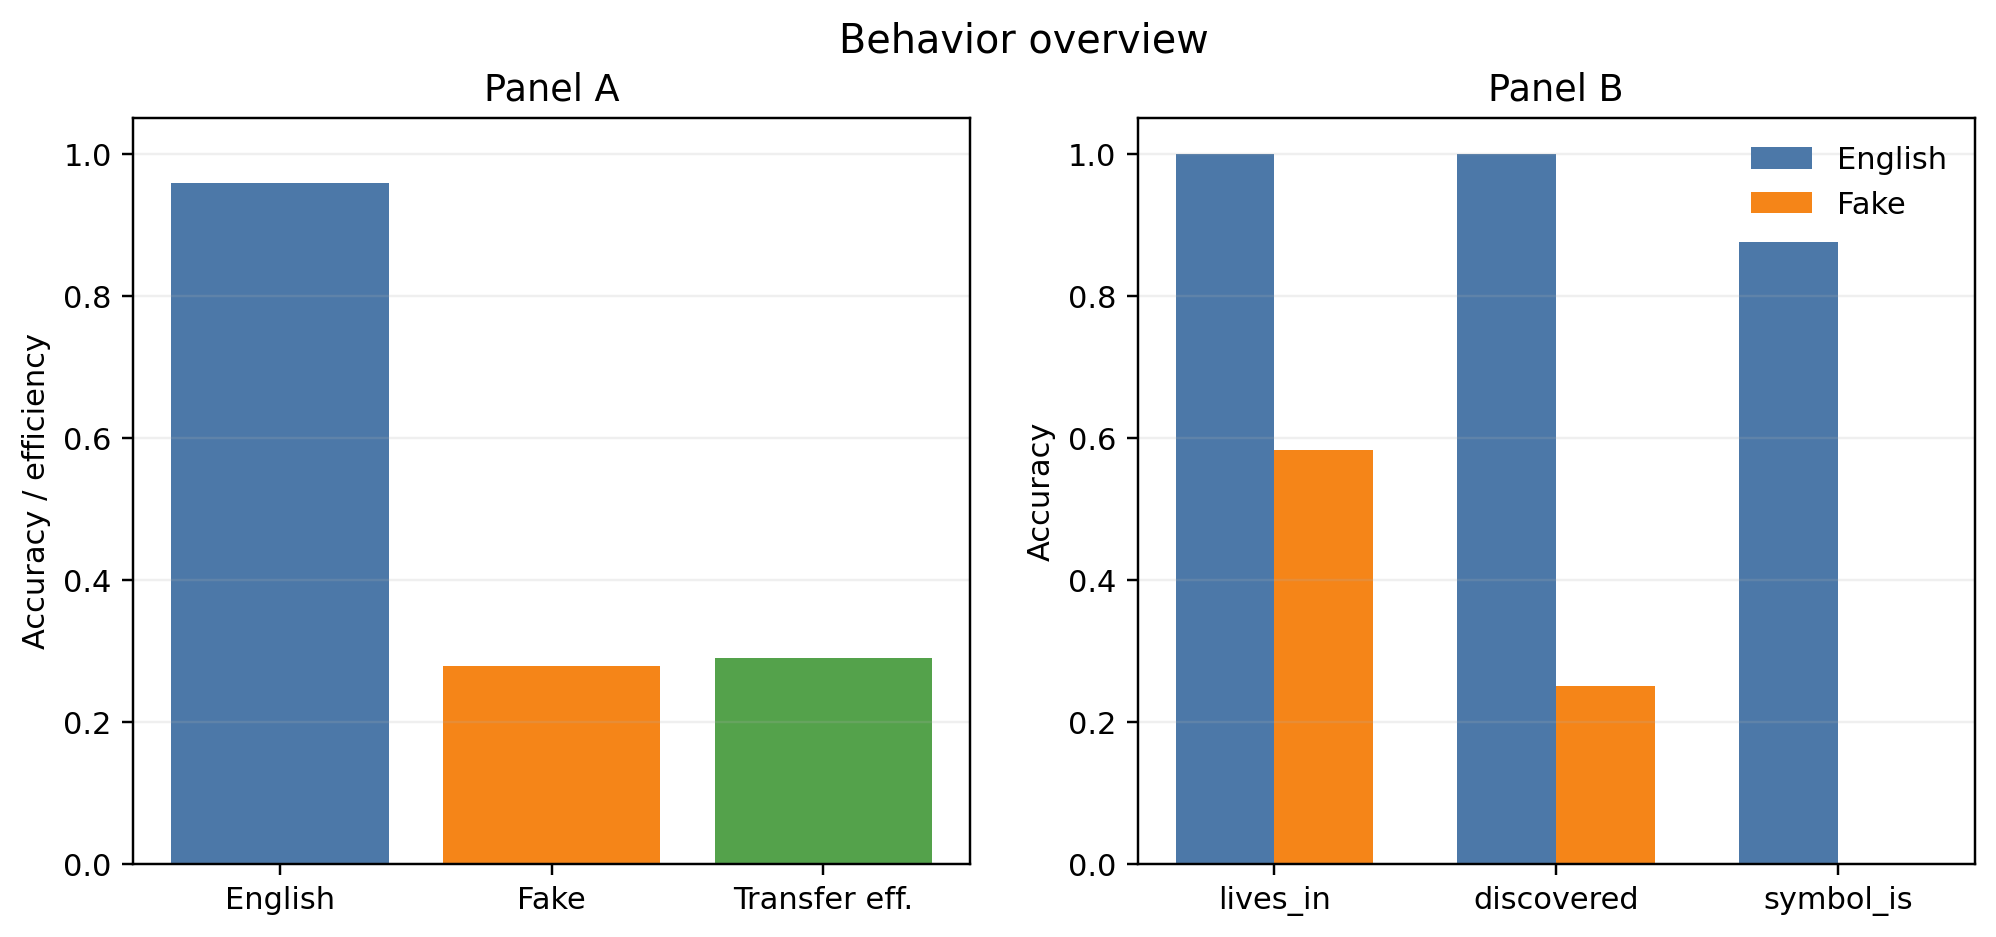

### Fake-Comprehension Control

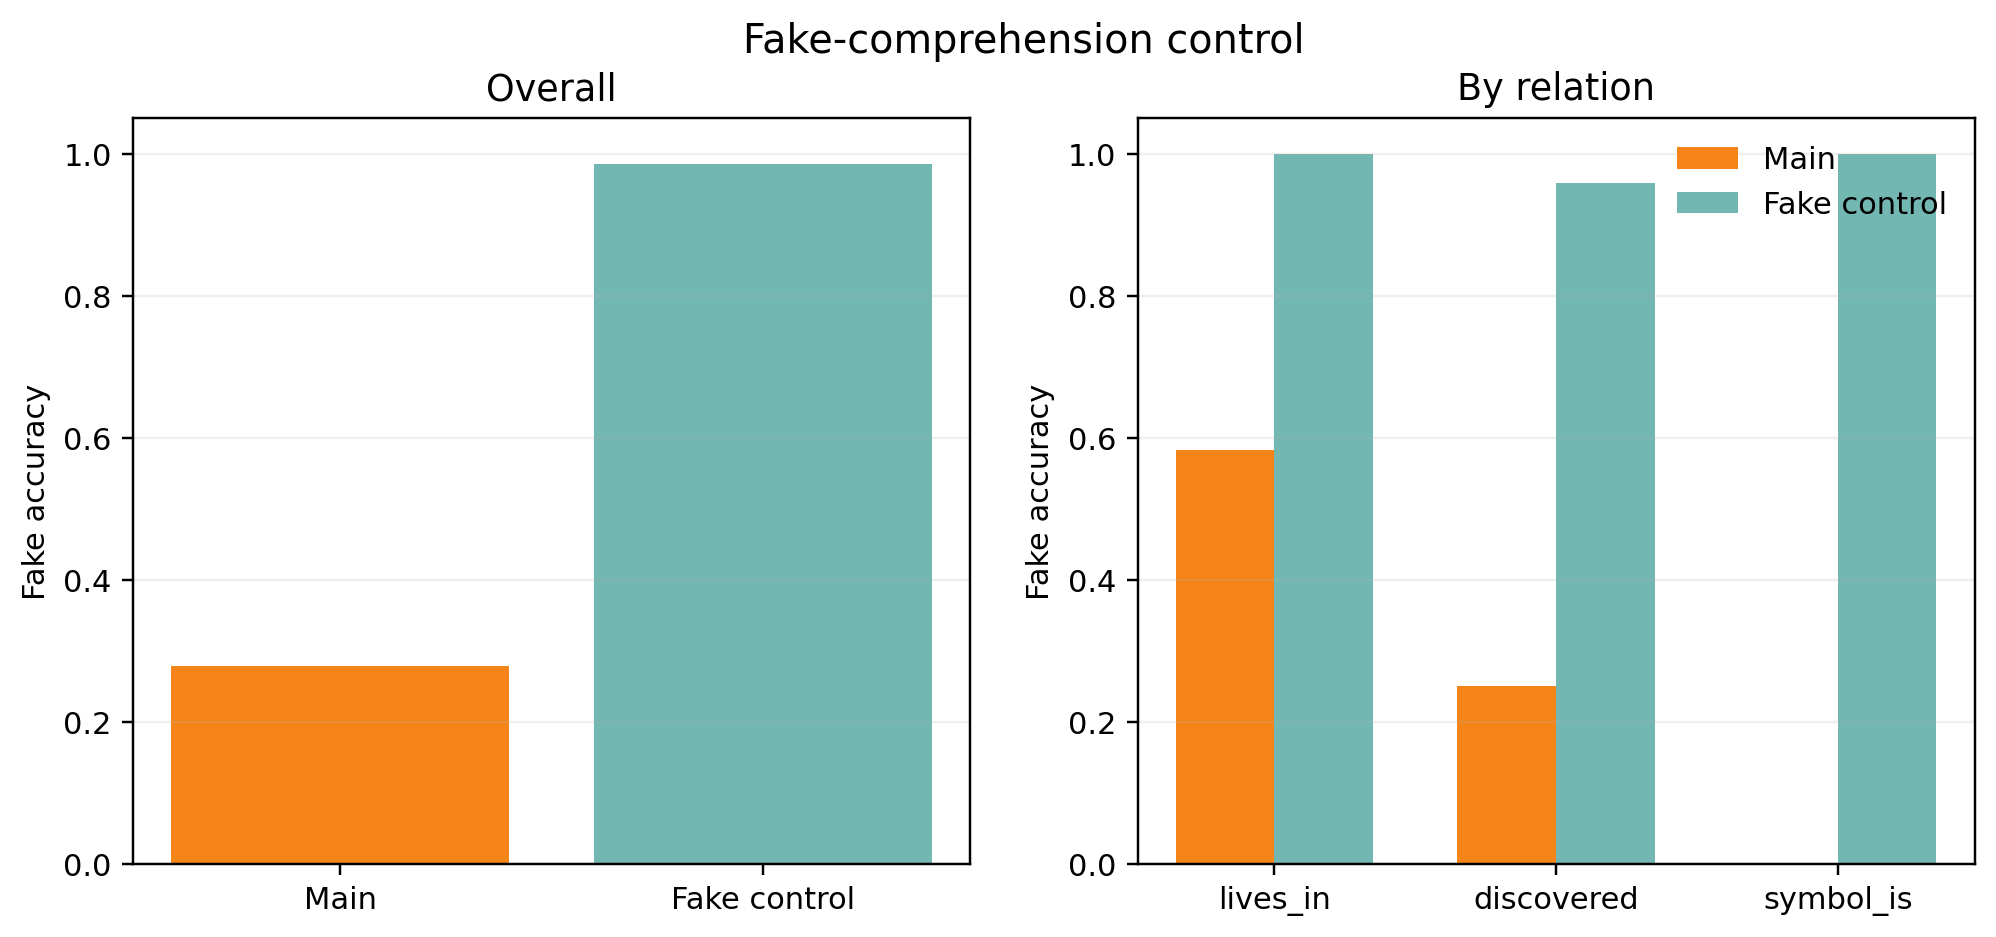

In [4]:
show_png('behavior_overview.png', 'Behavior Overview', width=1100)
show_png('fake_control_comparison.png', 'Fake-Comprehension Control', width=900)


**Behavior takeaway**

The behavioral gap is strong and clean. The main model learns English facts well but transfers only partially to Fake. The control model nearly saturates Fake performance, which rules out the explanation that Fake is intrinsically too difficult for the model.


## 4. Hidden-State Similarity

This section tests whether English and Fake prompts align internally at the subject level or the relation level.


In [5]:
overall_similarity = pd.DataFrame({
    'layer': list(range(len(sim_overall['subject_pool']['mean_similarity_by_layer']))),
    'subject_pool': sim_overall['subject_pool']['mean_similarity_by_layer'],
    'relation_pool': sim_overall['relation_pool']['mean_similarity_by_layer'],
    'final_token': sim_overall['final_token']['mean_similarity_by_layer'],
})

overall_similarity.head(12)


,layer,subject_pool,relation_pool,final_token
0,0,0.871094,0.051025,0.648438
1,1,0.917969,0.220703,0.757812
2,2,0.882812,0.169922,0.738281
3,3,0.878906,0.206055,0.781250
4,4,0.863281,0.251953,0.769531
5,5,0.863281,0.279297,0.750000
6,6,0.867188,0.283203,0.750000
7,7,0.878906,0.300781,0.781250
8,8,0.871094,0.345703,0.781250
9,9,0.859375,0.324219,0.785156


### Similarity Overall

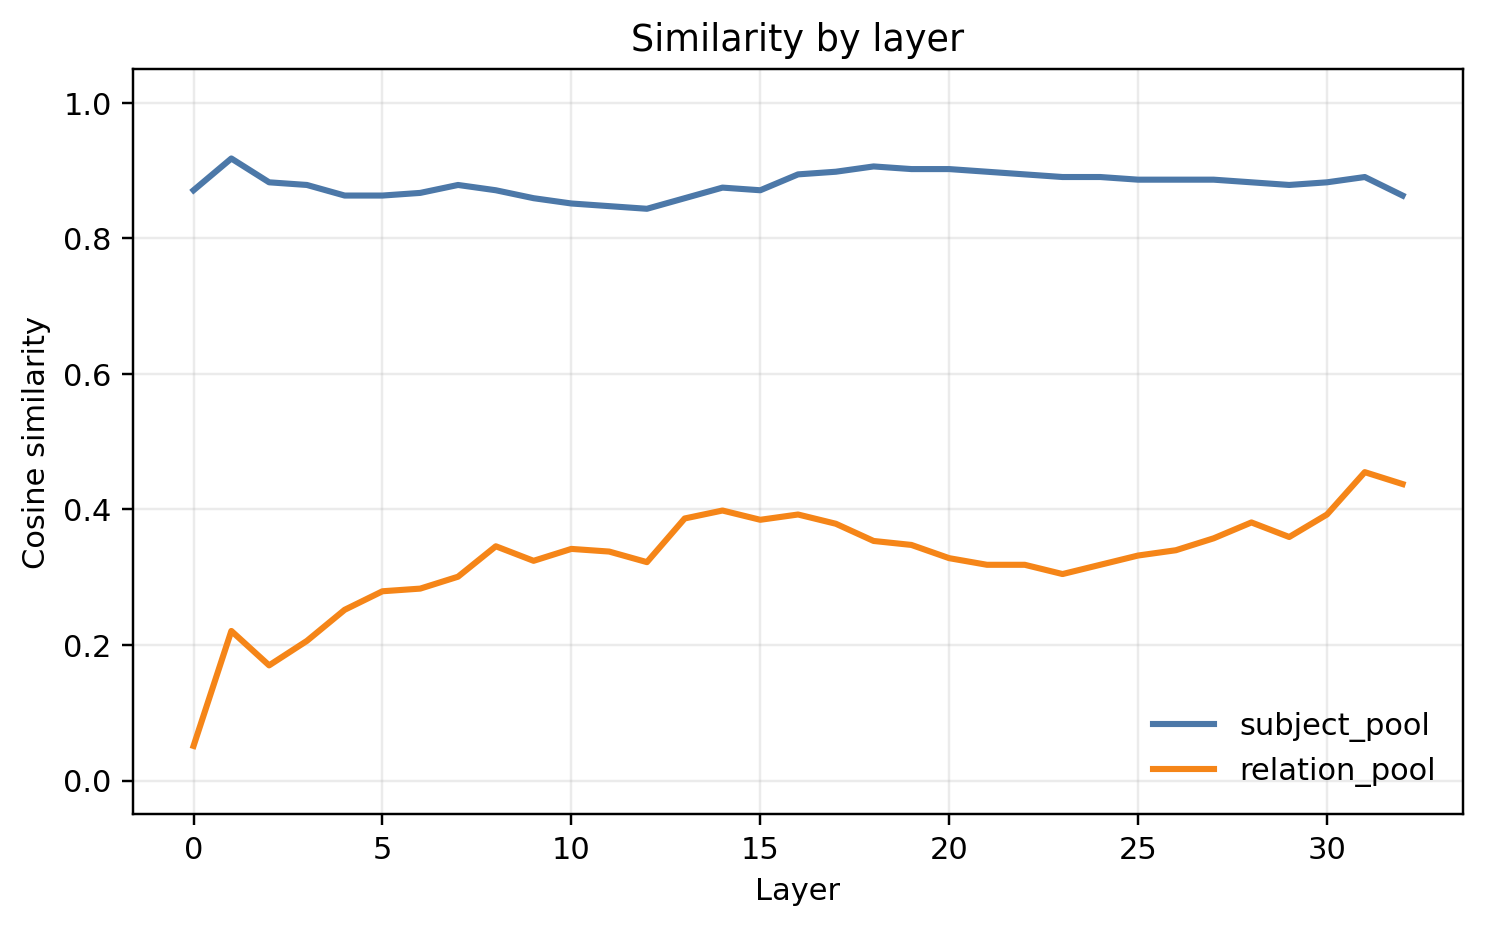

### Similarity by Relation

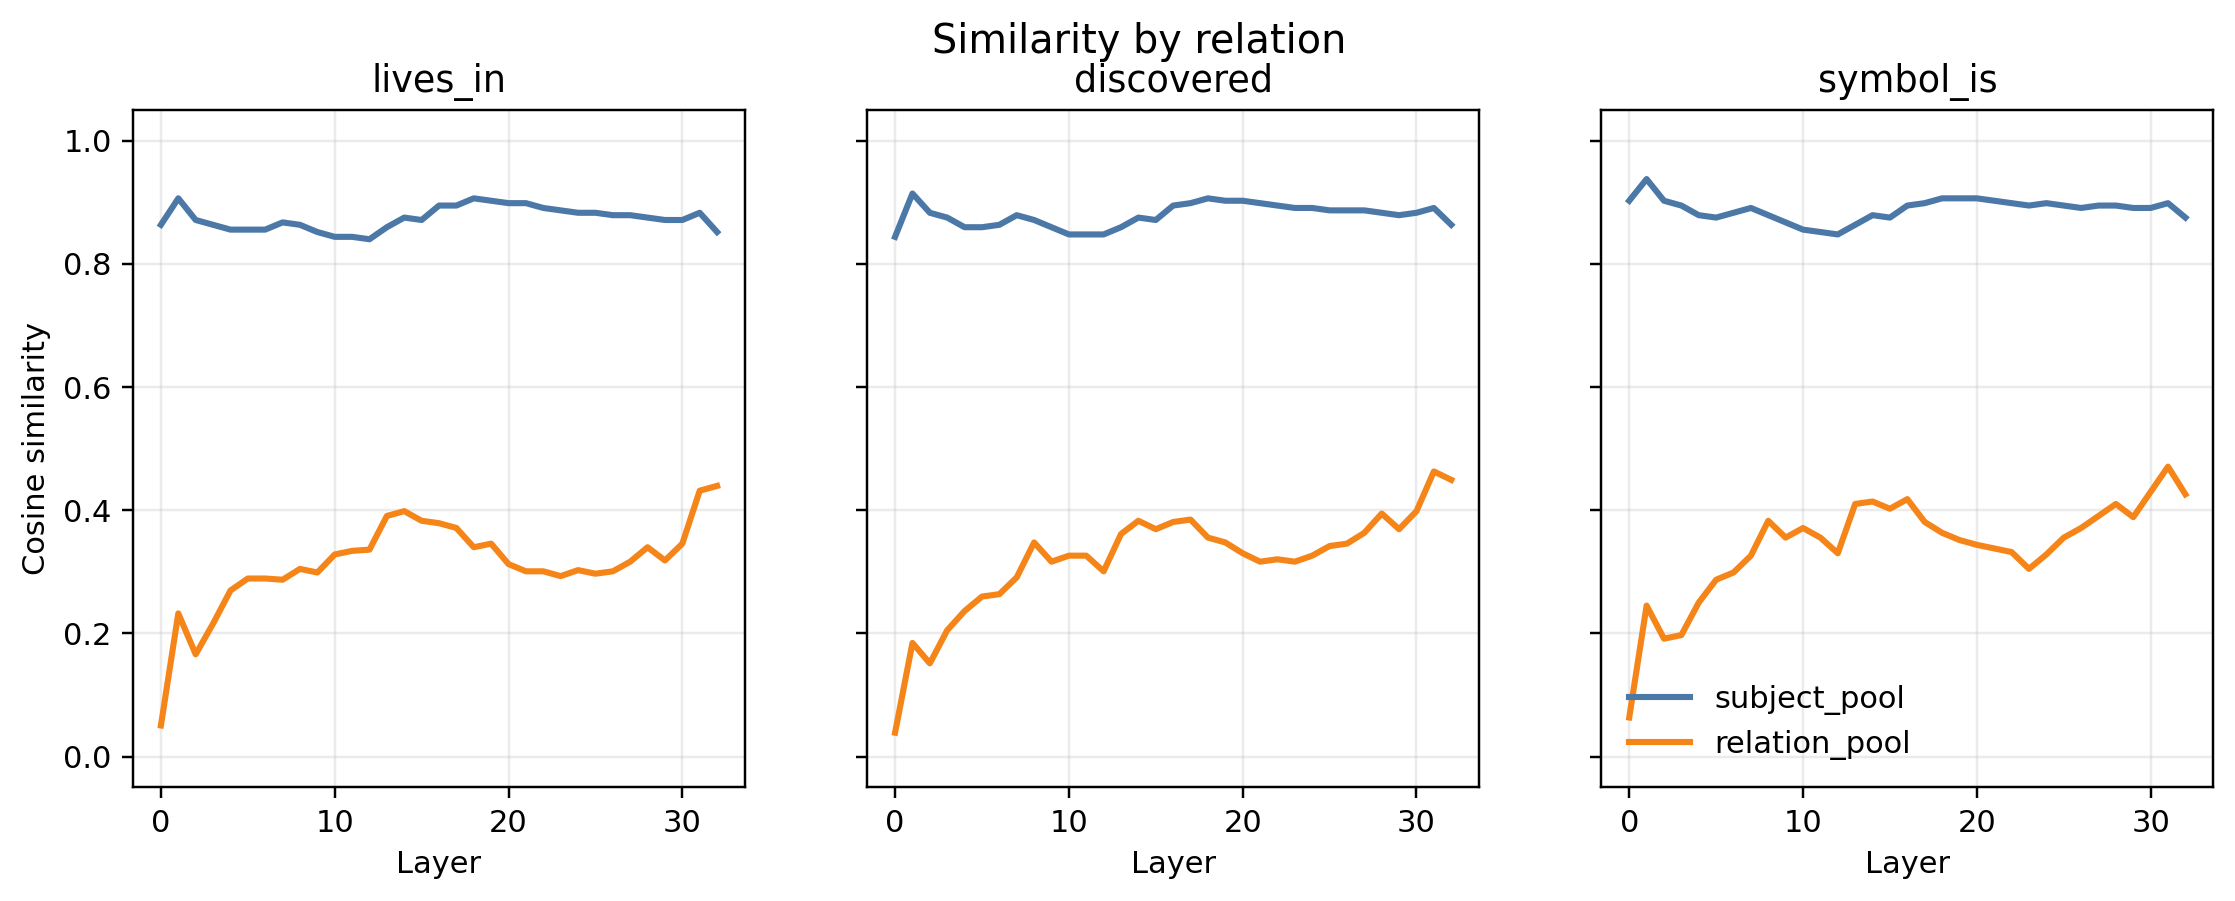

In [6]:
show_png('similarity_overall_main.png', 'Similarity Overall', width=900)
show_png('similarity_by_relation_main.png', 'Similarity by Relation', width=1200)


**Similarity takeaway**

Subject representations are highly aligned across English and Fake, while relation representations are much less aligned. This already suggests that the main bottleneck is not subject recognition but relation-specific processing.


## 5. Activation Patching

This section provides causal evidence. We patch English activations into Fake prompts for test pairs where English is correct and Fake is wrong.


In [7]:
patch_selection


{'selection_mode': 'english_correct_fake_wrong',
 'target_relations': ['lives_in', 'discovered', 'symbol_is'],
 'min_pairs_per_relation': 10,
 'max_pairs_total': 30,
 'available_pairs_by_relation': {'lives_in': 10,
  'discovered': 18,
  'symbol_is': 21},
 'selected_pairs_by_relation': {'lives_in': 10,
  'discovered': 10,
  'symbol_is': 10},
 'warnings': [],
 'run_name': 'main_qlora',
 'split': 'test',
 'selected_pair_count': 30,
 'selected_relation_distribution': {'lives_in': 10,
  'discovered': 10,
  'symbol_is': 10}}

In [8]:
overall_patch_table = pd.DataFrame([
    {
        'layer': layer,
        'subject_rescue': patch_overall['subject_last_token'][str(layer)]['rescue_rate_top1'],
        'relation_rescue': patch_overall['relation_last_token'][str(layer)]['rescue_rate_top1'],
        'final_rescue': patch_overall['final_token'][str(layer)]['rescue_rate_top1'],
    }
    for layer in range(32)
])

overall_patch_table.head(12)


,layer,subject_rescue,relation_rescue,final_rescue
0,0,0.033333,0.566667,0.033333
1,1,0.066667,0.566667,0.066667
2,2,0.066667,0.600000,0.033333
3,3,0.066667,0.566667,0.066667
4,4,0.100000,0.666667,0.066667
5,5,0.100000,0.700000,0.066667
6,6,0.100000,0.700000,0.066667
7,7,0.100000,0.633333,0.133333
8,8,0.133333,0.600000,0.133333
9,9,0.133333,0.500000,0.166667


### Patching Overall Main

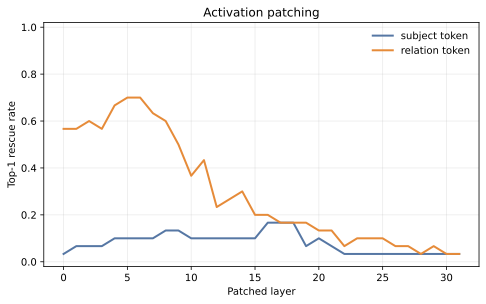

### Patching by Relation

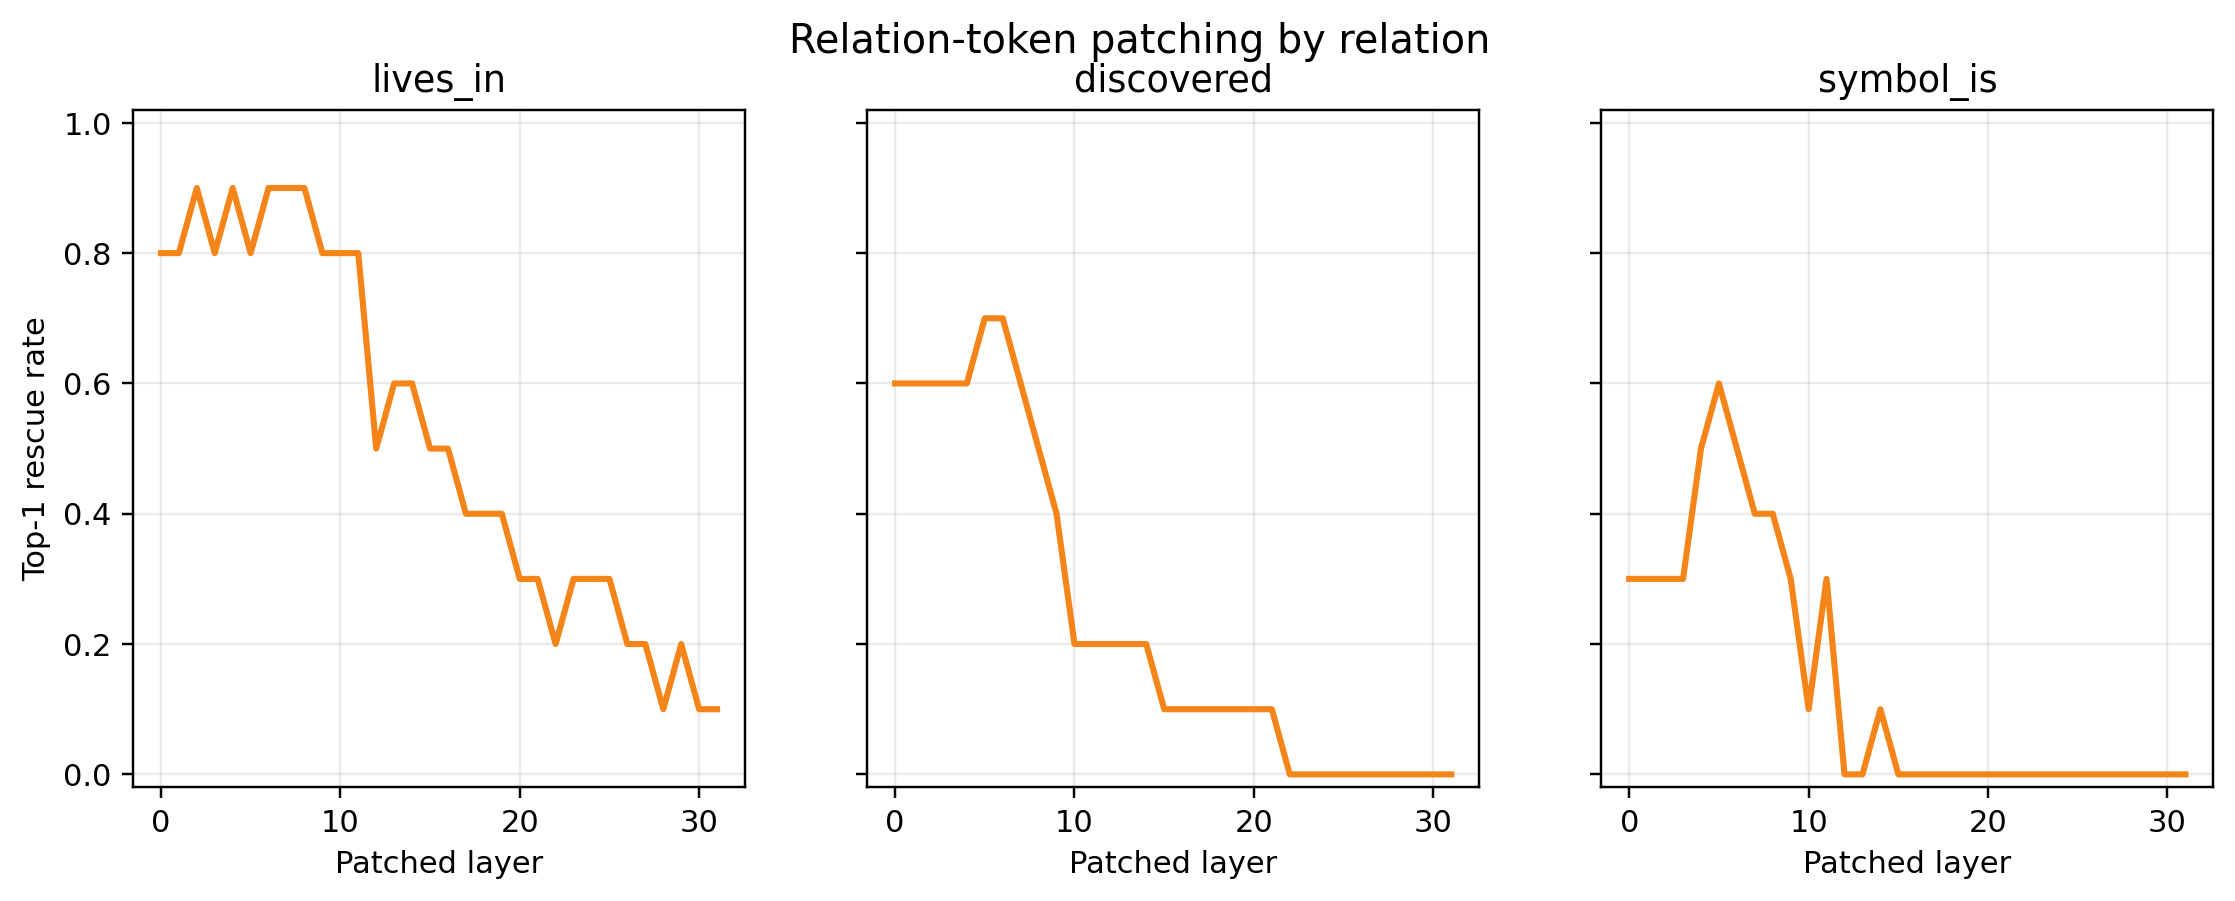

### Patching Heatmap: Overall Positions

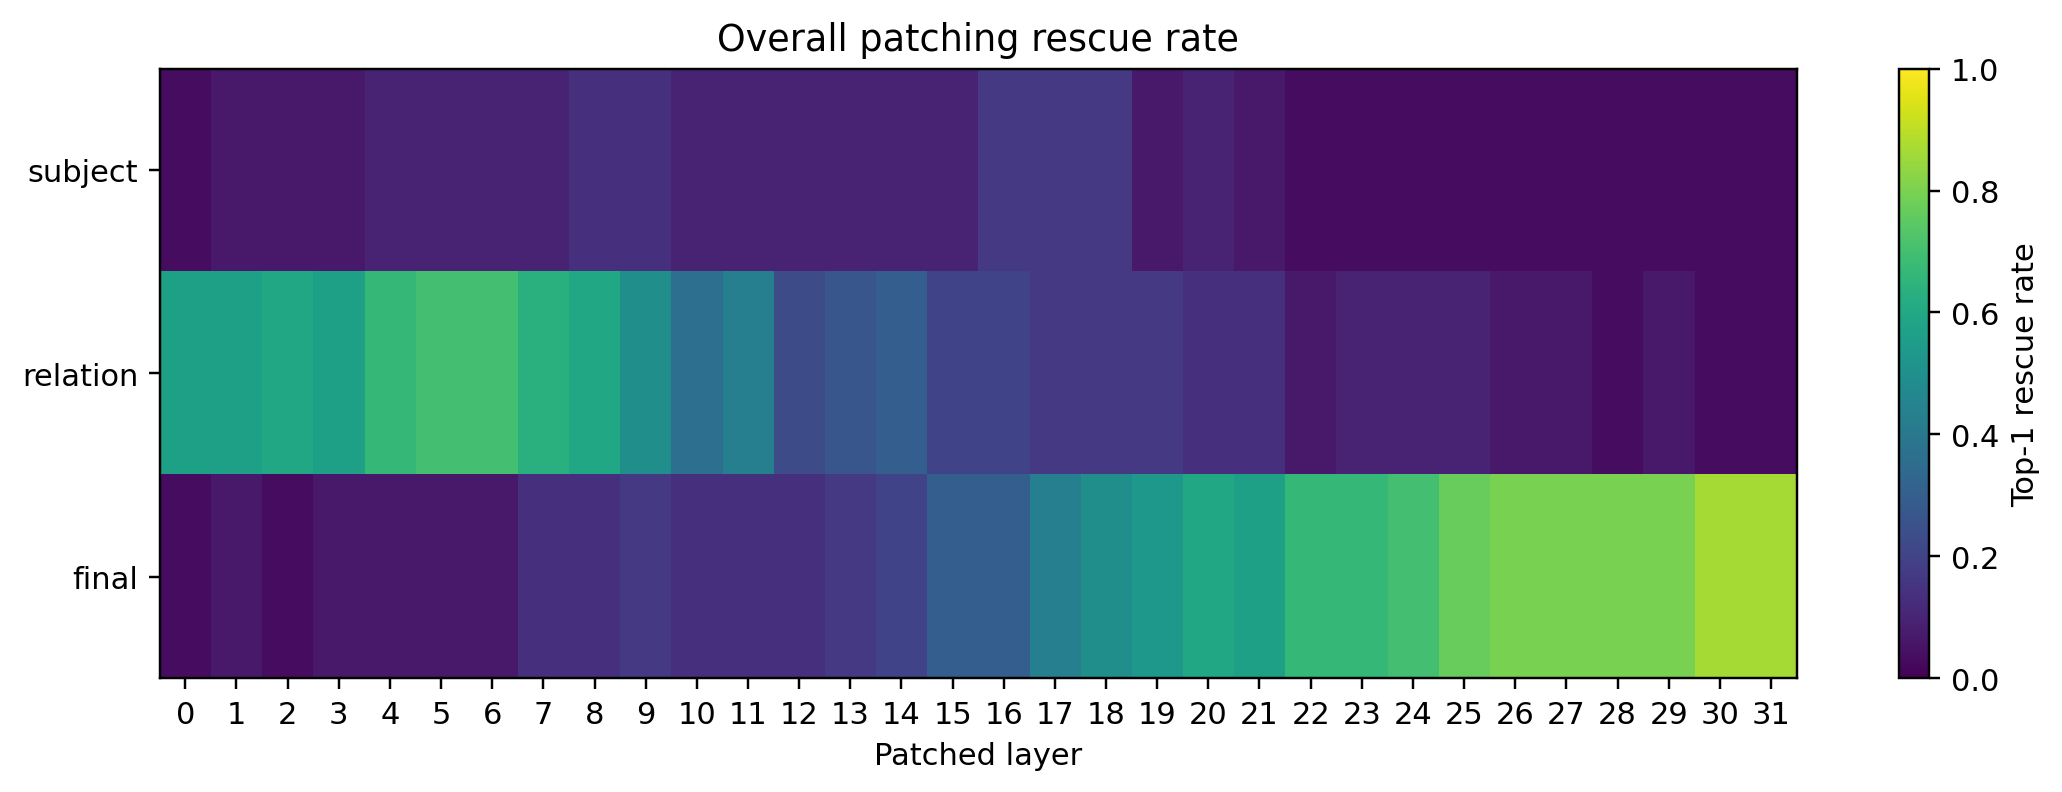

### Patching Heatmap: Relation Last Token

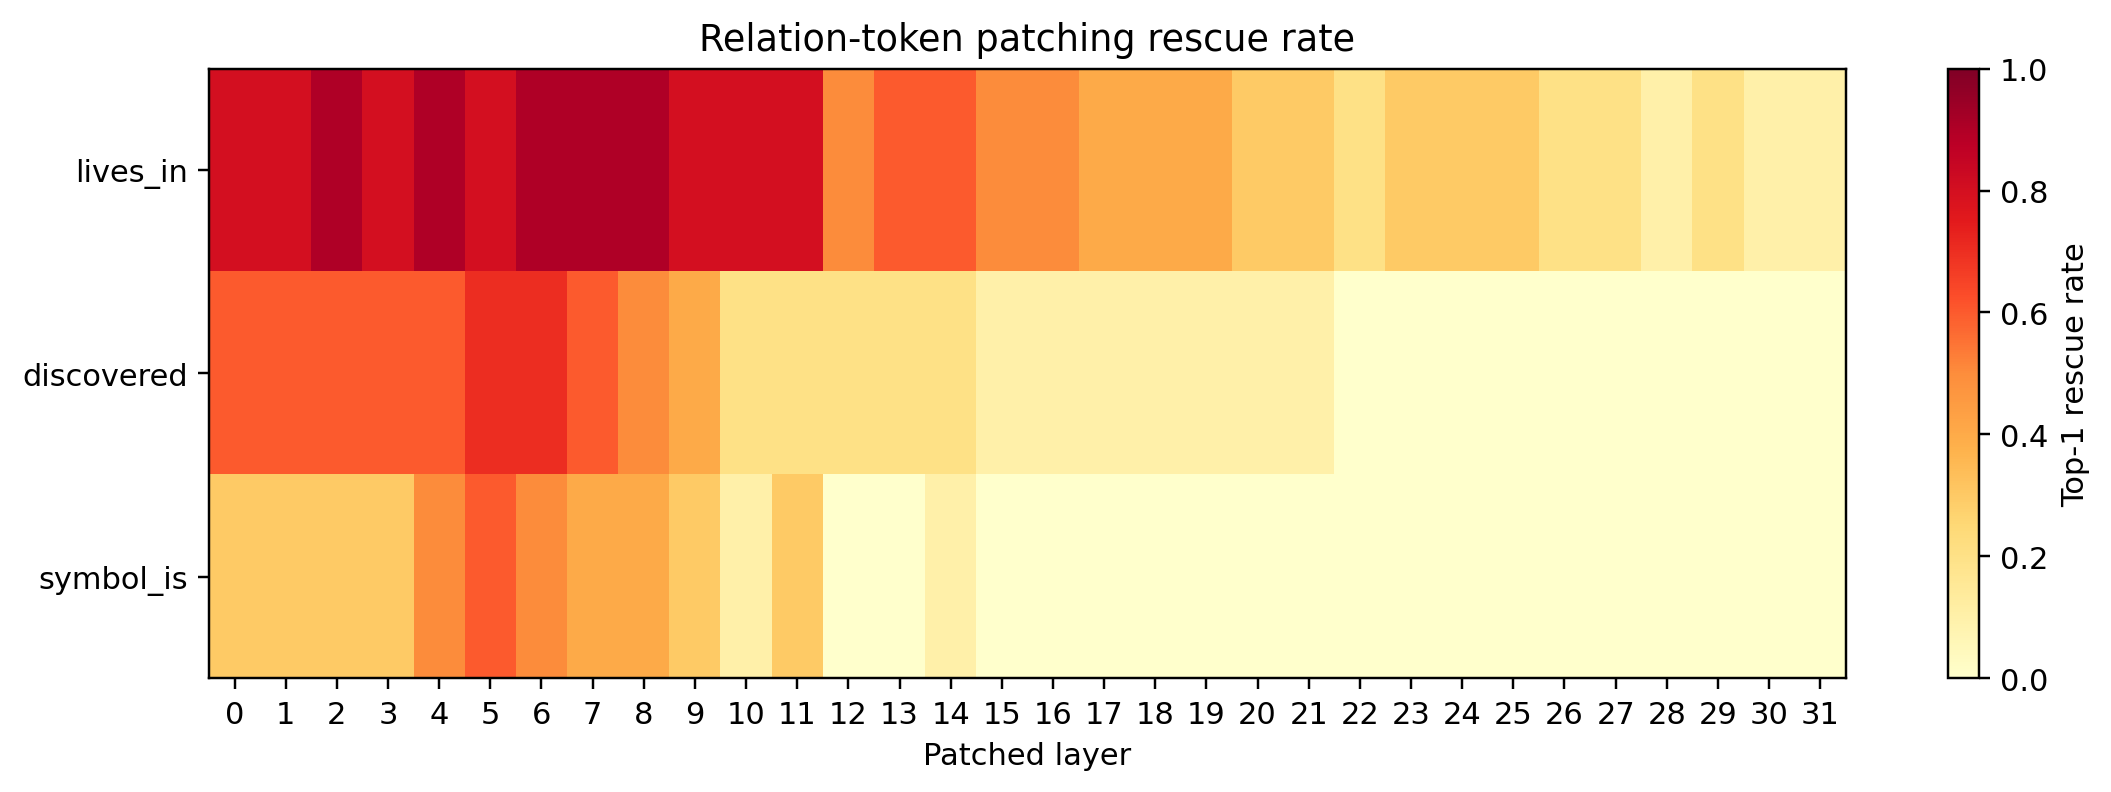

### Patching Heatmap: Final Token

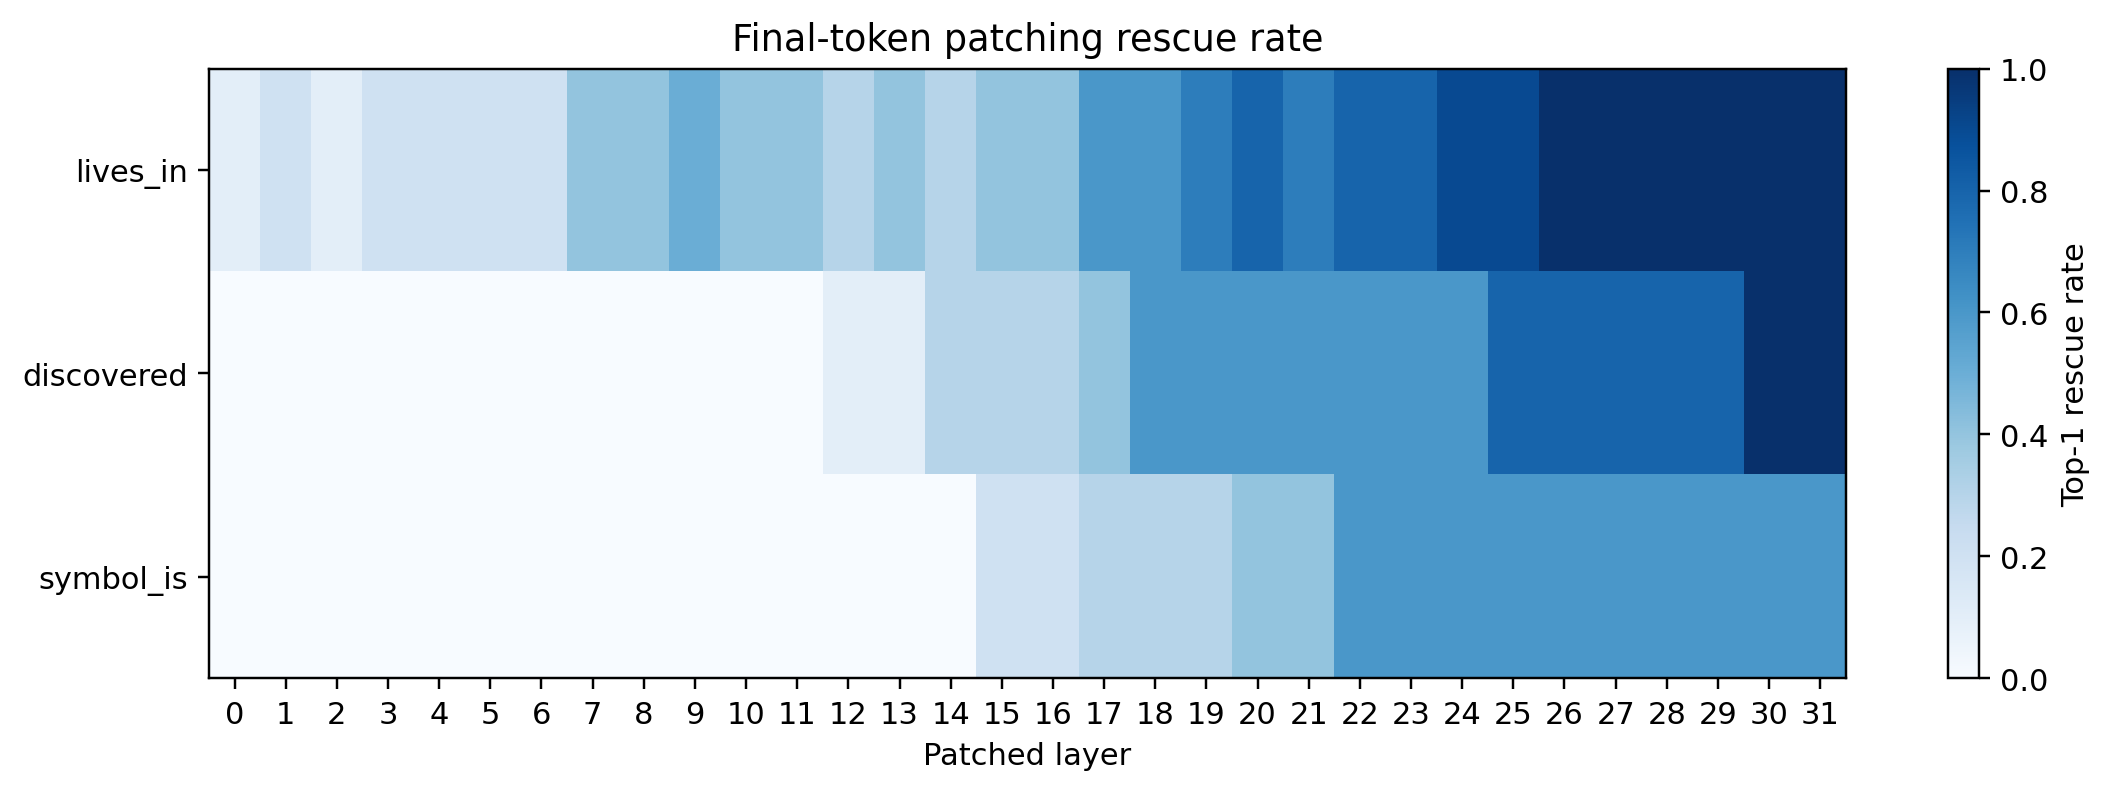

In [9]:
show_png('patching_overall_main.png', 'Patching Overall Main', width=900)
show_png('patching_by_relation_main.png', 'Patching by Relation', width=1200)
show_png('patching_heatmap_overall_positions.png', 'Patching Heatmap: Overall Positions', width=1100)
show_png('patching_heatmap_relation_last_token.png', 'Patching Heatmap: Relation Last Token', width=1100)
show_png('patching_heatmap_final_token.png', 'Patching Heatmap: Final Token', width=1100)


**Patching takeaway**

Relation-token patching is much stronger than subject-token patching, especially in early layers. Late final-token patching is also highly effective. This pattern supports a relation-level routing account of the transfer failure.
